# Multi-step Temperature Forecasting with GRU and Transformers
## Advanced Topics in Deep Learning — Mini-Project

**Objective:** Forecast future air temperature over a fixed prediction horizon using the Jena Climate dataset, comparing GRU and Transformer architectures.

**Pipeline:**
1. Data Loading & Initial Exploration
2. Exploratory Data Analysis (EDA)
3. Data Preparation (resampling, cleaning, splitting, normalization)
4. Windowing & Dataset Creation
5. Model Implementation (GRU & Transformer)
6. Evaluation & Comparative Analysis

Authors: David Isaac, Nº 120064, David Volovei, Nº 120051, Eduardo Martins Nº120063

---
## 1. Setup & Imports

In [5]:
import os
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from scipy import stats
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

SEED = 33 # Isaac's favourite number
np.random.seed(SEED)

---
## 2. Data Loading

We use the **Jena Climate** dataset, publicly available from the TensorFlow/Keras data repository.  
Source: https://keras.io/examples/timeseries/timeseries_weather_forecasting

The dataset contains meteorological measurements from a weather station in Jena, Germany, recorded every **10 minutes** from 2009 to 2016.

In [6]:
# Download and extract the dataset
DATA_URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
ZIP_PATH = "jena_climate_2009_2016.csv.zip"
CSV_PATH = "data/jena_climate_2009_2016.csv"

if not os.path.exists(CSV_PATH):
    os.makedirs('data', exist_ok=True)
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('data')
    os.remove(ZIP_PATH)  # Clean up zip file
    print("Dataset downloaded and extracted.")
else:
    print(f"Dataset already exists at '{CSV_PATH}'.")

# Load into DataFrame
df_raw = pd.read_csv(CSV_PATH)
print(f"\nRaw dataset shape: {df_raw.shape}")
df_raw.head()

Dataset already exists at 'data/jena_climate_2009_2016.csv'.

Raw dataset shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [7]:
# Quick overview of the raw data
print("Columns:")
for i, col in enumerate(df_raw.columns):
    print(f"  {i}: {col}")
print(f"\nDate range: {df_raw['Date Time'].iloc[0]} → {df_raw['Date Time'].iloc[-1]}")
print(f"Total records: {len(df_raw):,}")
df_raw.info()

Columns:
  0: Date Time
  1: p (mbar)
  2: T (degC)
  3: Tpot (K)
  4: Tdew (degC)
  5: rh (%)
  6: VPmax (mbar)
  7: VPact (mbar)
  8: VPdef (mbar)
  9: sh (g/kg)
  10: H2OC (mmol/mol)
  11: rho (g/m**3)
  12: wv (m/s)
  13: max. wv (m/s)
  14: wd (deg)

Date range: 01.01.2009 00:10:00 → 01.01.2017 00:00:00
Total records: 420,551
<class 'pandas.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420551 non-null  str    
 1   p (mbar)         420551 non-null  float64
 2   T (degC)         420551 non-null  float64
 3   Tpot (K)         420551 non-null  float64
 4   Tdew (degC)      420551 non-null  float64
 5   rh (%)           420551 non-null  float64
 6   VPmax (mbar)     420551 non-null  float64
 7   VPact (mbar)     420551 non-null  float64
 8   VPdef (mbar)     420551 non-null  float64
 9   sh (g/kg)        420551 non-null  float64
 10

### 2.1 Variable Selection

As specified in the assignment, we must use only the following variables:

| Variable | Description |
|---|---|
| `T (degC)` | Air temperature (target) |
| `p (mbar)` | Atmospheric pressure |
| `rh (%)` | Relative humidity |
| `wv (m/s)` | Wind speed |
| `max. wv (m/s)` | Maximum wind speed |
| `wd (deg)` | Wind direction |


In [8]:
# Select only the required variables initially from df_raw
SELECTED_FEATURES_RAW = ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

# Parse datetime and set as index
df = df_raw[['Date Time'] + SELECTED_FEATURES_RAW].copy()
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time')
df = df.sort_index()

# Rename columns for clarity
feature_mapping = {
    'T (degC)': 'Temperature',
    'p (mbar)': 'Pressure',
    'rh (%)': 'Humidity',
    'wv (m/s)': 'WindSpeed',
    'max. wv (m/s)': 'MaxWindSpeed',
    'wd (deg)': 'WindDir'
}
df = df.rename(columns=feature_mapping)

# Update target and features variables to match the new mappings
TARGET = 'Temperature'
SELECTED_FEATURES = list(feature_mapping.values())
print(f"Selected dataset shape: {df.shape}")
print(f"Date range: {df.index[0]} → {df.index[-1]}")
print(f"Sampling frequency: ~{(df.index[1] - df.index[0]).total_seconds() / 60:.0f} minutes")
df.head(10)

Selected dataset shape: (420551, 6)
Date range: 2009-01-01 00:10:00 → 2017-01-01 00:00:00
Sampling frequency: ~10 minutes


,Temperature,Pressure,Humidity,WindSpeed,MaxWindSpeed,WindDir
Date Time,,,,,,
2009-01-01 00:10:00,-8.02,996.52,93.3,1.03,1.75,152.3
2009-01-01 00:20:00,-8.41,996.57,93.4,0.72,1.50,136.1
2009-01-01 00:30:00,-8.51,996.53,93.9,0.19,0.63,171.6
2009-01-01 00:40:00,-8.31,996.51,94.2,0.34,0.50,198.0
2009-01-01 00:50:00,-8.27,996.51,94.1,0.32,0.63,214.3
2009-01-01 01:00:00,-8.05,996.50,94.4,0.21,0.63,192.7
2009-01-01 01:10:00,-7.62,996.50,94.8,0.18,0.63,166.5
2009-01-01 01:20:00,-7.62,996.50,94.4,0.19,0.50,118.6
2009-01-01 01:30:00,-7.91,996.50,93.8,0.28,0.75,188.5


In [9]:
# Descriptive statistics
df.describe().round(2)

,Temperature,Pressure,Humidity,WindSpeed,MaxWindSpeed,WindDir
count,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00
mean,9.45,989.21,76.01,1.70,3.06,174.74
std,8.42,8.36,16.48,65.45,69.02,86.68
min,-23.01,913.60,12.95,-9999.00,-9999.00,0.00
25%,3.36,984.20,65.21,0.99,1.76,124.90
50%,9.42,989.58,79.30,1.76,2.96,198.10
75%,15.47,994.72,89.40,2.86,4.74,234.10
max,37.28,1015.35,100.00,28.49,23.50,360.00


In [10]:
df["Temperature"].describe()

count    420551.000000
mean          9.450147
std           8.423365
min         -23.010000
25%           3.360000
50%           9.420000
75%          15.470000
max          37.280000
Name: Temperature, dtype: float64

C:\Users\edmdu\AppData\Local\Temp\ipykernel_18964\1837185492.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_min_per_month.index, y=avg_min_per_month.values, palette="Blues_d")


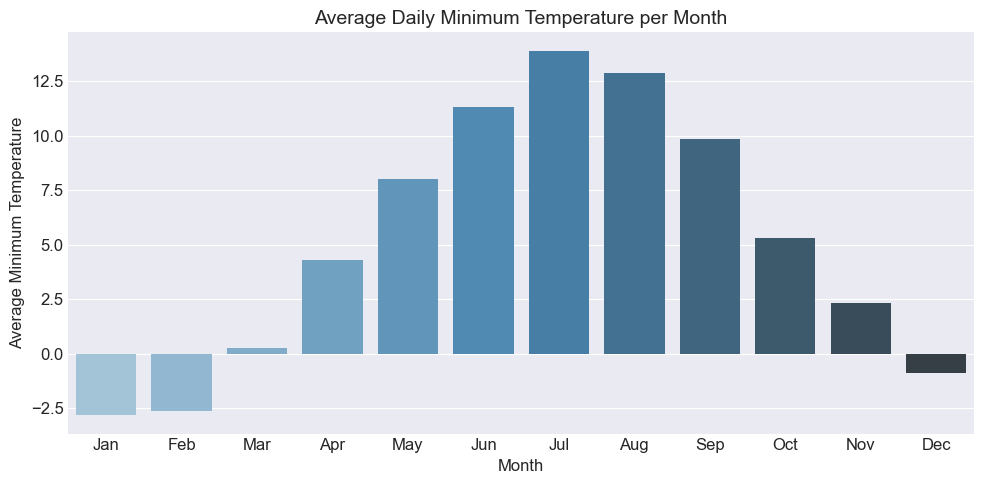

C:\Users\edmdu\AppData\Local\Temp\ipykernel_18964\1837185492.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Month', y='Temperature', palette="Set3")


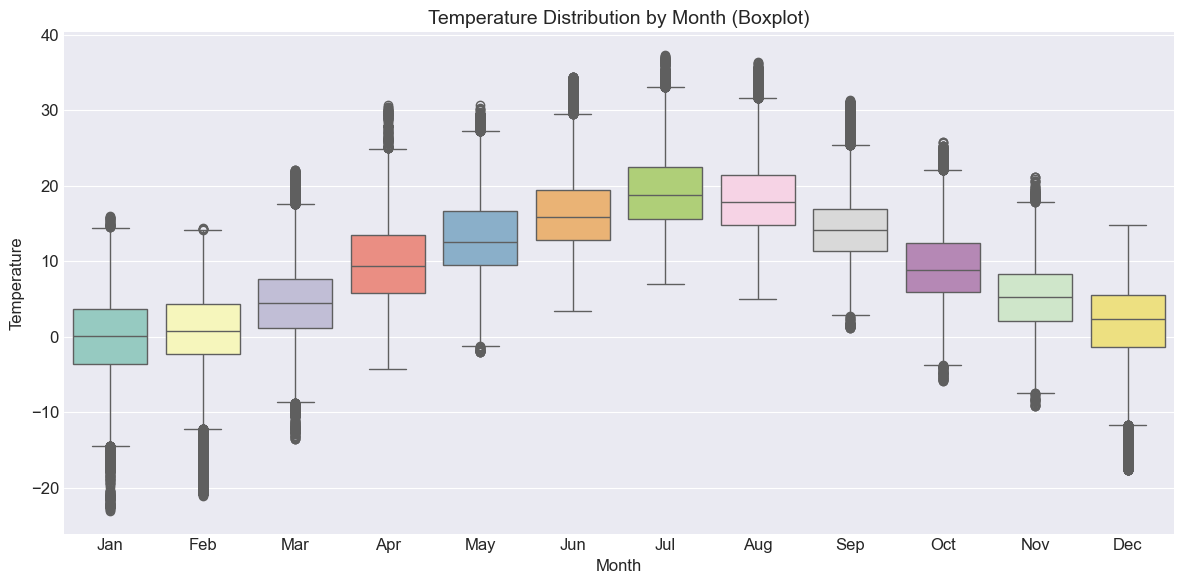

In [11]:
# Extract the minimum temperature per day
daily_min = df['Temperature'].resample('D').min()

# Group the daily minimums by month (1 to 12) and calculate the mean
avg_min_per_month = daily_min.groupby(daily_min.index.month).mean()

# Bar chart of average minimums
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_min_per_month.index, y=avg_min_per_month.values, palette="Blues_d")

# Configure labels and title
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=range(12), labels=months)
plt.title('Average Daily Minimum Temperature per Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Minimum Temperature', fontsize=12)
plt.tight_layout()
plt.show()

# Add a temporary 'Month' column for the boxplot
df['Month'] = df.index.month
# Create a Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Month', y='Temperature', palette="Set3")

# Configure labels and title
plt.xticks(ticks=range(12), labels=months)
plt.title('Temperature Distribution by Month (Boxplot)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Temperature', fontsize=12)
plt.tight_layout()
plt.show()
# Drop the 'Month' column since it's no longer needed
df = df.drop(columns=['Month'])

---
## 3. Exploratory Data Analysis (EDA)

Before building any model, we need to understand the structure and characteristics of the data:
- Are there **missing values** or **anomalies**?
- What are the **trends** and **seasonal patterns**?
- How are the variables **correlated**?
- What are the **distributions** of each variable?

### 3.1 Missing Values & Data Quality

In [12]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

print("Missing values per column:")
for col in df.columns:
    print(f"  {col:20s}: {missing[col]:5d} ({missing_pct[col]:.2f}%)")

print(f"\nTotal missing values: {missing.sum()}")

Missing values per column:
  Temperature         :     0 (0.00%)
  Pressure            :     0 (0.00%)
  Humidity            :     0 (0.00%)
  WindSpeed           :     0 (0.00%)
  MaxWindSpeed        :     0 (0.00%)
  WindDir             :     0 (0.00%)

Total missing values: 0


In [13]:
# Check for duplicate timestamps
n_duplicates = df.index.duplicated().sum() 
print(f"Duplicate timestamps: {n_duplicates}")

# see timestamps with duplicates
if n_duplicates > 0:
    dup_timestamps = df.index[df.index.duplicated()]
    # see count of duplicates per timestamp
    dup_counts = df.index.value_counts()[dup_timestamps]
    print("\nDuplicate timestamps and their counts:")
    for ts, count in dup_counts.items():
        print(f"  {ts}: {count} occurrences")

    # see example of duplicate entries
    print("\nExample of duplicate entries:")
    print(df[df.index.duplicated(keep=False)].head(10))

Duplicate timestamps: 327

Duplicate timestamps and their counts:
  2010-07-01 00:10:00: 2 occurrences
  2010-07-01 00:20:00: 2 occurrences
  2010-07-01 00:30:00: 2 occurrences
  2010-07-01 00:40:00: 2 occurrences
  2010-07-01 00:50:00: 2 occurrences
  2010-07-01 01:00:00: 2 occurrences
  2010-07-01 01:10:00: 2 occurrences
  2010-07-01 01:20:00: 2 occurrences
  2010-07-01 01:30:00: 2 occurrences
  2010-07-01 01:40:00: 2 occurrences
  2010-07-01 01:50:00: 2 occurrences
  2010-07-01 02:00:00: 2 occurrences
  2010-07-01 02:10:00: 2 occurrences
  2010-07-01 02:20:00: 2 occurrences
  2010-07-01 02:30:00: 2 occurrences
  2010-07-01 02:40:00: 2 occurrences
  2010-07-01 02:50:00: 2 occurrences
  2010-07-01 03:00:00: 2 occurrences
  2010-07-01 03:10:00: 2 occurrences
  2010-07-01 03:20:00: 2 occurrences
  2010-07-01 03:30:00: 2 occurrences
  2010-07-01 03:40:00: 2 occurrences
  2010-07-01 03:50:00: 2 occurrences
  2010-07-01 04:00:00: 2 occurrences
  2010-07-01 04:10:00: 2 occurrences
  2010-07

In [14]:
# Check for gaps in the time series (expected: 10 min intervals)
time_diffs = df.index.to_series().diff().dropna()
expected_freq = pd.Timedelta(minutes=10)
gaps = time_diffs[time_diffs != expected_freq]

print(f"\nExpected interval: {expected_freq}")
print(f"Number of irregular intervals: {len(gaps)}")
if len(gaps) > 0:
    print(f"\nSample of irregular gaps:")
    print(gaps.head(10))

# see irregular intervals in more detail
if len(gaps) > 0:
    print("\nIrregular intervals and their counts:")
    gap_counts = gaps.value_counts()
    for gap, count in gap_counts.items():
        print(f"  {gap}: {count} occurrences")

#see example of irregular intervals
if len(gaps) > 0:
    print("\nExample of irregular intervals:")
    for gap in gap_counts.index:
        print(f"\nEntries around gap of {gap}:")
        gap_indices = time_diffs[time_diffs == gap].index
        for idx in gap_indices[:5]:  # Show up to 5 examples per gap type
            print(df.loc[idx - pd.Timedelta(minutes=20): idx + pd.Timedelta(minutes=20)])


Expected interval: 0 days 00:10:00
Number of irregular intervals: 332

Sample of irregular gaps:
Date Time
2009-10-08 10:10:00   0 days 00:30:00
2010-07-01 00:10:00   0 days 00:00:00
2010-07-01 00:20:00   0 days 00:00:00
2010-07-01 00:30:00   0 days 00:00:00
2010-07-01 00:40:00   0 days 00:00:00
2010-07-01 00:50:00   0 days 00:00:00
2010-07-01 01:00:00   0 days 00:00:00
2010-07-01 01:10:00   0 days 00:00:00
2010-07-01 01:20:00   0 days 00:00:00
2010-07-01 01:30:00   0 days 00:00:00
Name: Date Time, dtype: timedelta64[us]

Irregular intervals and their counts:
  0 days 00:00:00: 327 occurrences
  0 days 00:20:00: 2 occurrences
  0 days 00:30:00: 1 occurrences
  0 days 16:00:00: 1 occurrences
  3 days 02:20:00: 1 occurrences

Example of irregular intervals:

Entries around gap of 0 days 00:00:00:
                     Temperature  Pressure  Humidity  WindSpeed  MaxWindSpeed  \
Date Time                                                                       
2010-06-30 23:50:00        18.0

In [15]:
# Check for anomalous values
# Wind speed should not be negative, temperature should be in a realistic range, etc...

print("Potential anomalies:")
print(f"  Negative wind speed (wv):     {(df['WindSpeed'] < 0).sum()} records")
print(f"  Negative wind speed (max wv): {(df['MaxWindSpeed'] < 0).sum()} records")
print(f"  Wind direction < 0 or > 360:  {((df['WindDir'] < 0) | (df['WindDir'] > 360)).sum()} records")
print(f"  Temperature < -30°C:          {(df['Temperature'] < -30).sum()} records")
print(f"  Temperature > 50°C:           {(df['Temperature'] > 50).sum()} records")

# Specifically look at extreme wind speed values
print(f"\nWind speed (wv) max value: {df['WindSpeed'].max():.2f} m/s")
print(f"Max wind speed (max wv) max value: {df['MaxWindSpeed'].max():.2f} m/s")

# values like 999.99 are clearly sensor errors
wv_outliers = df[df['WindSpeed'] > 50]
max_wv_outliers = df[df['MaxWindSpeed'] > 50]
print(f"\nWind speed > 50 m/s (likely sensor errors): {len(wv_outliers)} records")
print(f"Max wind speed > 50 m/s (likely sensor errors): {len(max_wv_outliers)} records")

Potential anomalies:
  Negative wind speed (wv):     18 records
  Negative wind speed (max wv): 20 records
  Wind direction < 0 or > 360:  0 records
  Temperature < -30°C:          0 records
  Temperature > 50°C:           0 records

Wind speed (wv) max value: 28.49 m/s
Max wind speed (max wv) max value: 23.50 m/s

Wind speed > 50 m/s (likely sensor errors): 0 records
Max wind speed > 50 m/s (likely sensor errors): 0 records


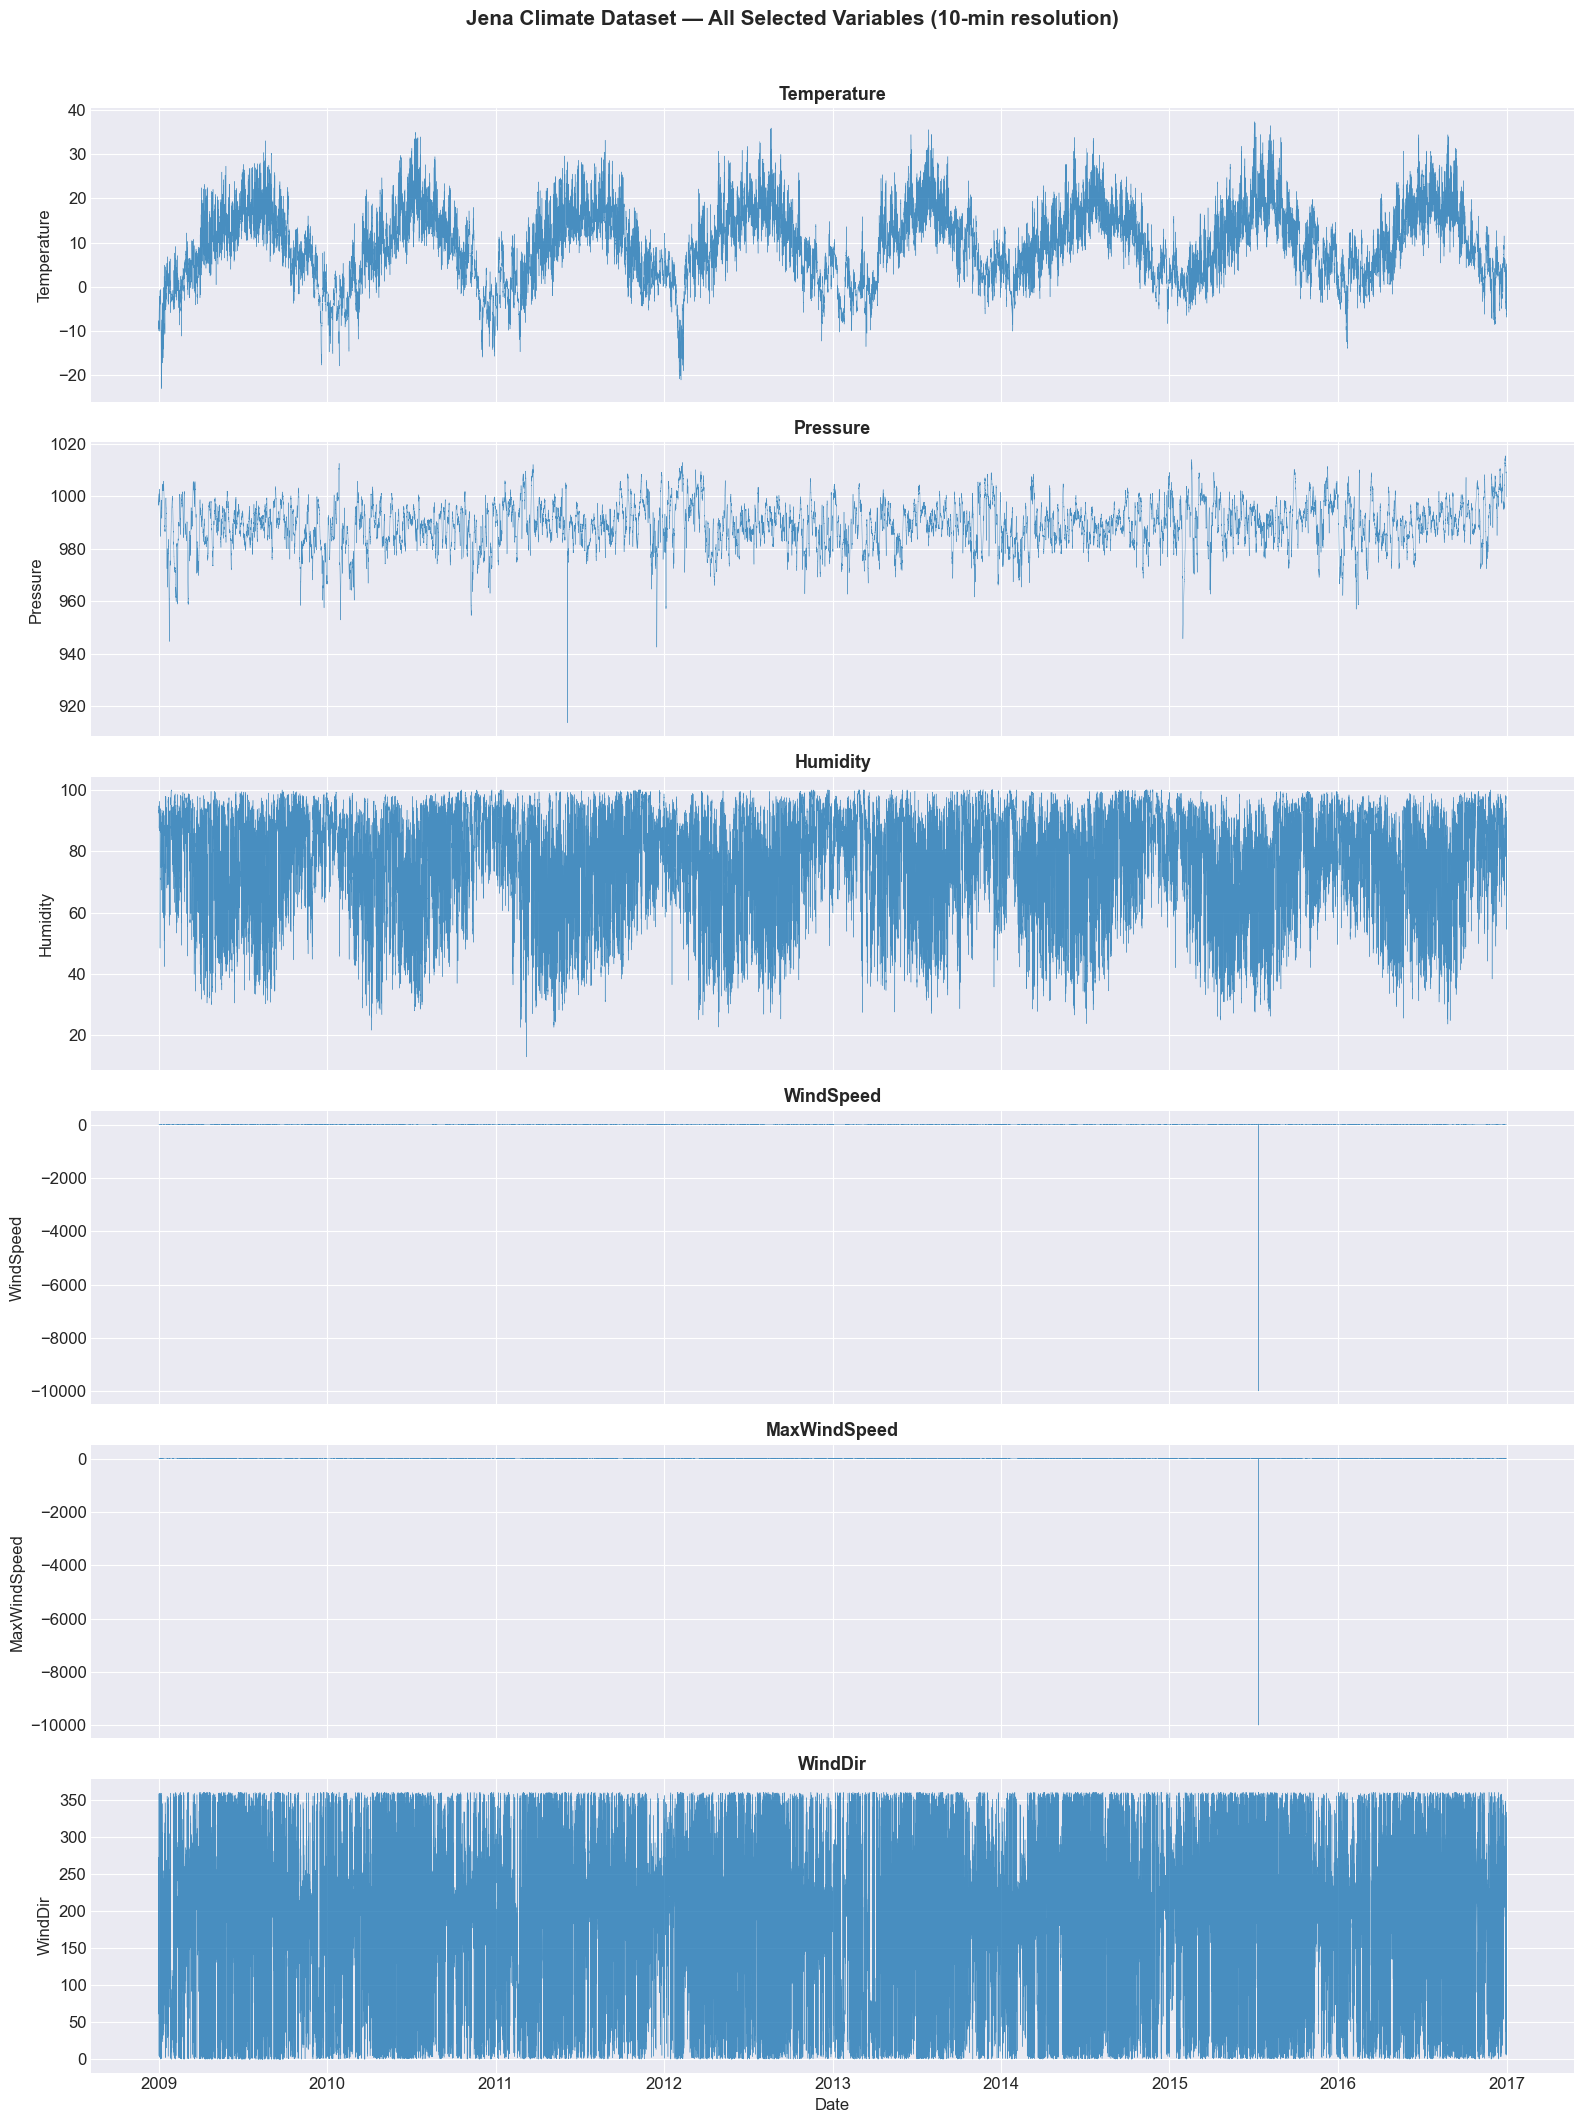

In [16]:
# Plot all variables over time
fig, axes = plt.subplots(len(SELECTED_FEATURES), 1, figsize=(16, 3.5 * len(SELECTED_FEATURES)), sharex=True)

for i, col in enumerate(SELECTED_FEATURES):
    axes[i].plot(df.index, df[col], linewidth=0.3, alpha=0.8)
    axes[i].set_ylabel(col)
    axes[i].set_title(col, fontsize=13, fontweight='bold')

axes[-1].set_xlabel('Date')
fig.suptitle('Jena Climate Dataset — All Selected Variables (10-min resolution)', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2. Taking care of the irregular values

In [17]:
## substite negative wind speed with values close to the values of that time step on that day
df_test = df.copy()

def sub_negative_wind_speed(df, column):
    # Identify negative wind speed records
    negative_mask = df[column] < 0
    n_negative = negative_mask.sum()
    print(f"Substituting {n_negative} negative values in '{column}'")
    if n_negative == 0:
        return df
    # For each negative value, substitute with the median of that time step across all days
    for idx in df[negative_mask].index:
        time_of_day = idx.time()
        # Get all values at this time of day (ignoring date)
        same_time_values = df[df.index.time == time_of_day][column]
        median_value = same_time_values[same_time_values >= 0].median()  # Use only non-negative values for median
        df.at[idx, column] = median_value

    return df

# Substitute negative wind speed values
df = sub_negative_wind_speed(df, 'WindSpeed')
df = sub_negative_wind_speed(df, 'MaxWindSpeed')

print(f"  Negative wind speed (wv):     {(df['WindSpeed'] < 0).sum()} records")
print(f"  Negative wind speed (max wv): {(df['MaxWindSpeed'] < 0).sum()} records")

Substituting 18 negative values in 'WindSpeed'
Substituting 20 negative values in 'MaxWindSpeed'
  Negative wind speed (wv):     0 records
  Negative wind speed (max wv): 0 records


### 3.3 Time Series Visualization

Let's visualize all selected variables over the full time span to identify trends, seasonality, and any visible anomalies.

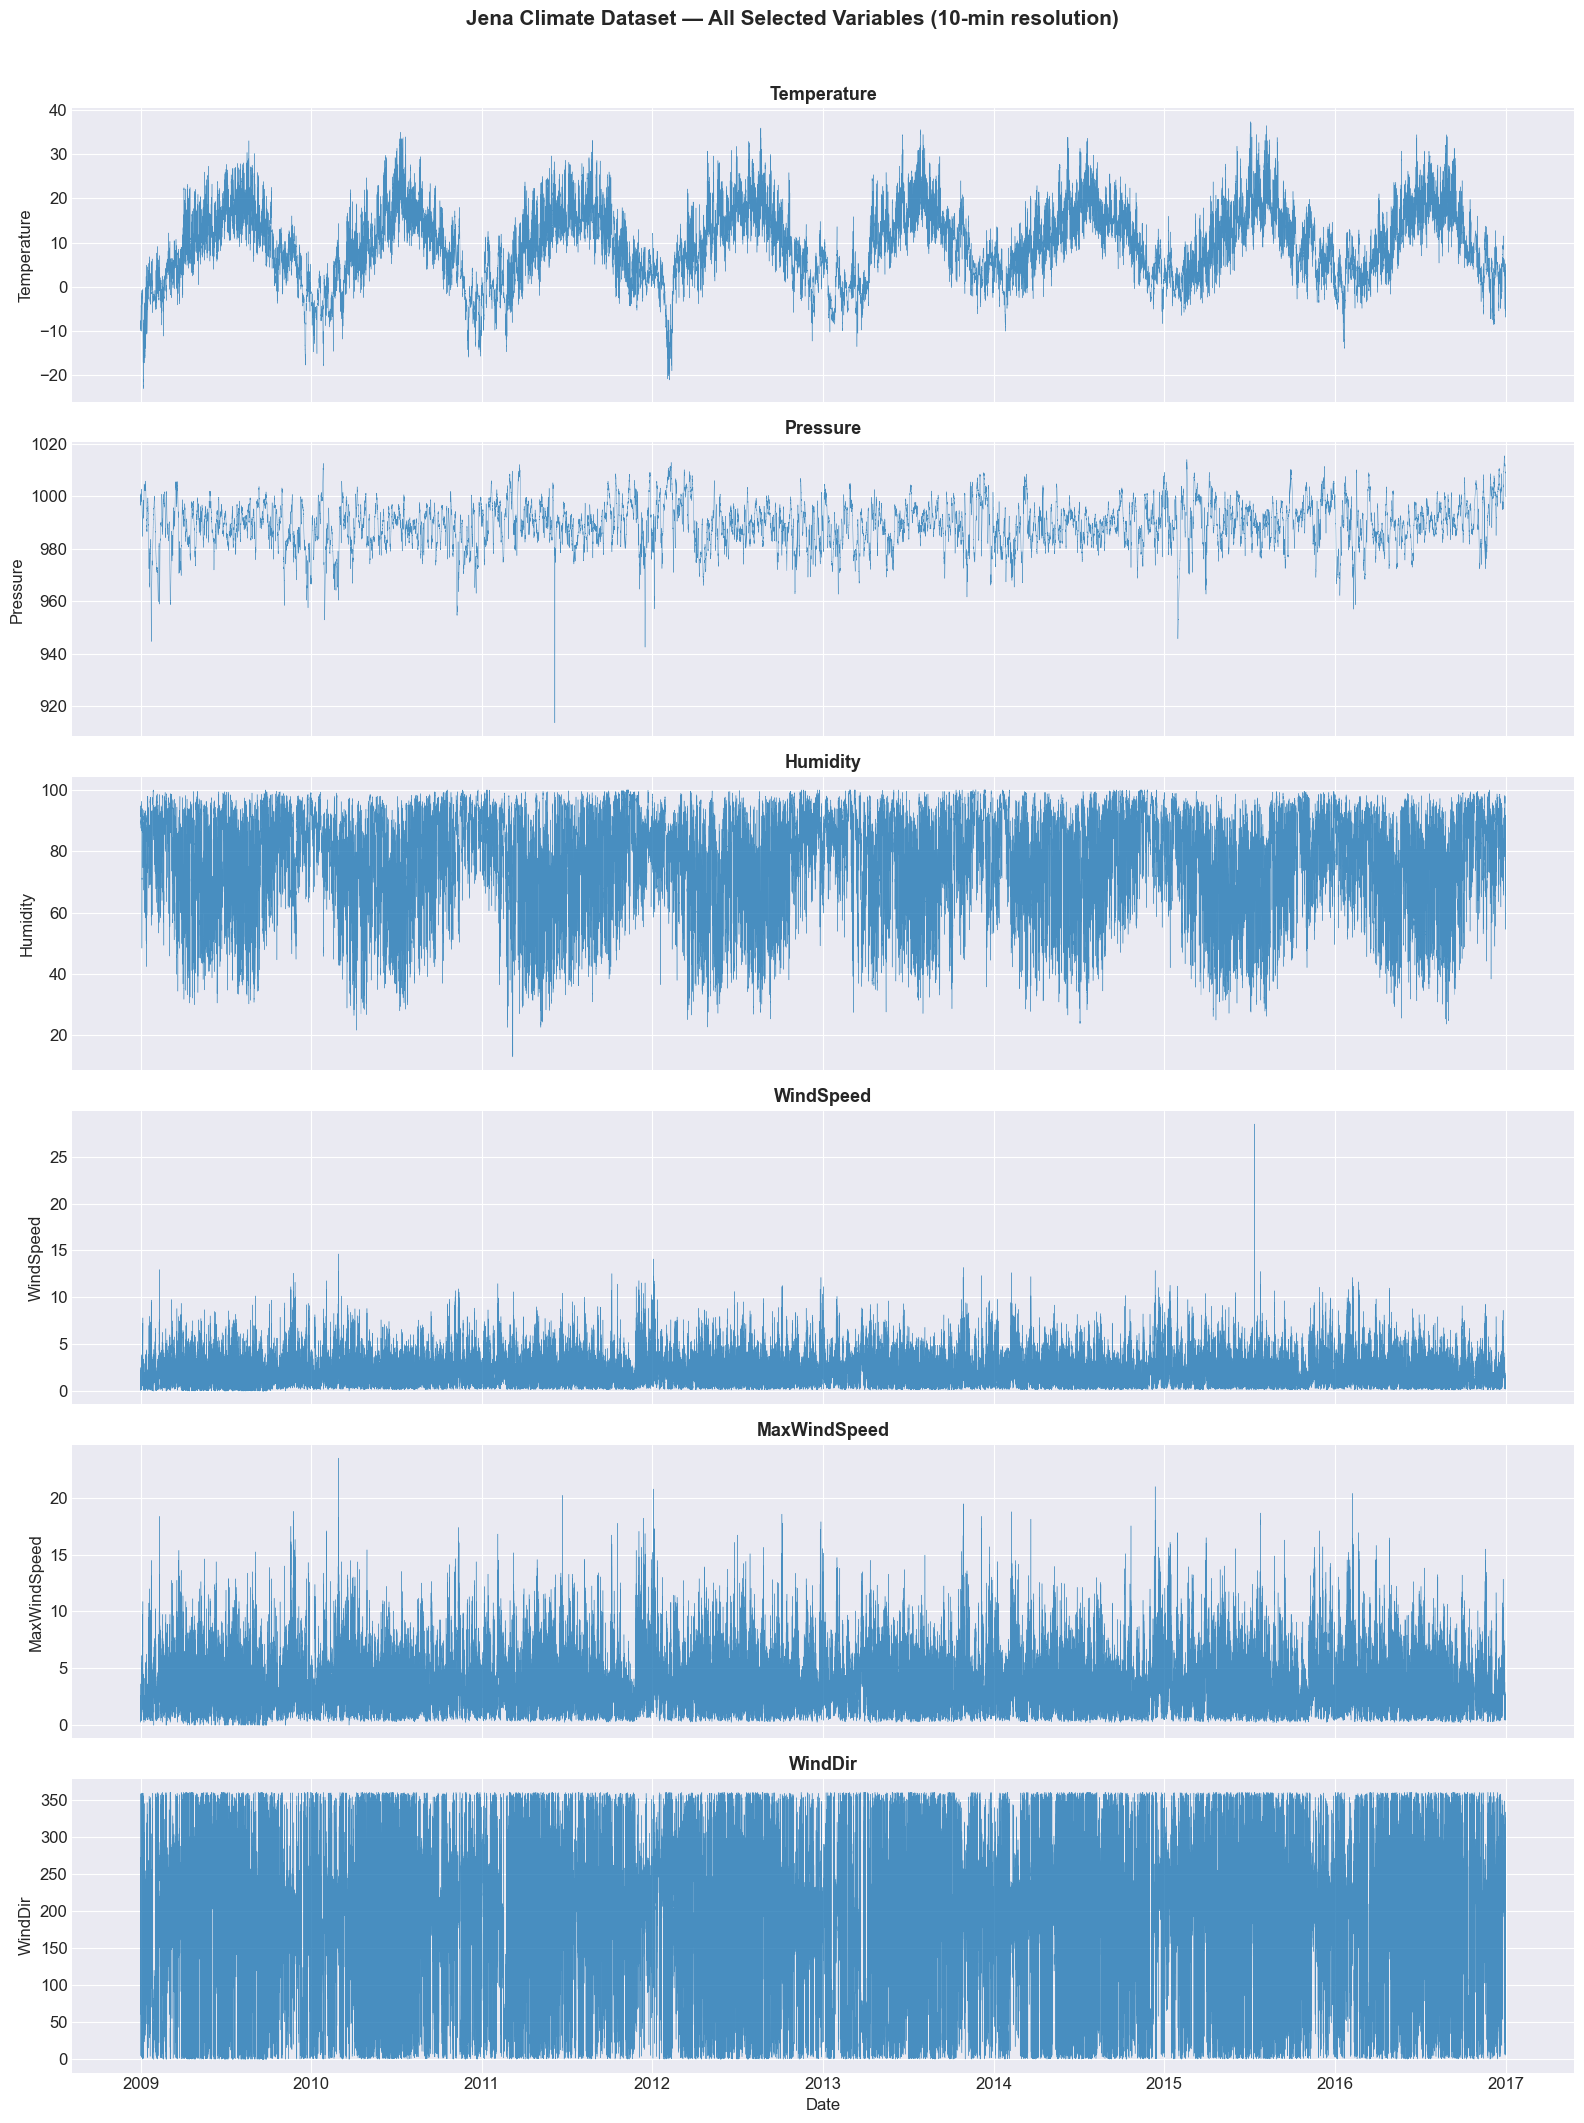

In [18]:
# Plot all variables over time
fig, axes = plt.subplots(len(SELECTED_FEATURES), 1, figsize=(16, 3.5 * len(SELECTED_FEATURES)), sharex=True)

for i, col in enumerate(SELECTED_FEATURES):
    axes[i].plot(df.index, df[col], linewidth=0.3, alpha=0.8)
    axes[i].set_ylabel(col)
    axes[i].set_title(col, fontsize=13, fontweight='bold')

axes[-1].set_xlabel('Date')
fig.suptitle('Jena Climate Dataset — All Selected Variables (10-min resolution)', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

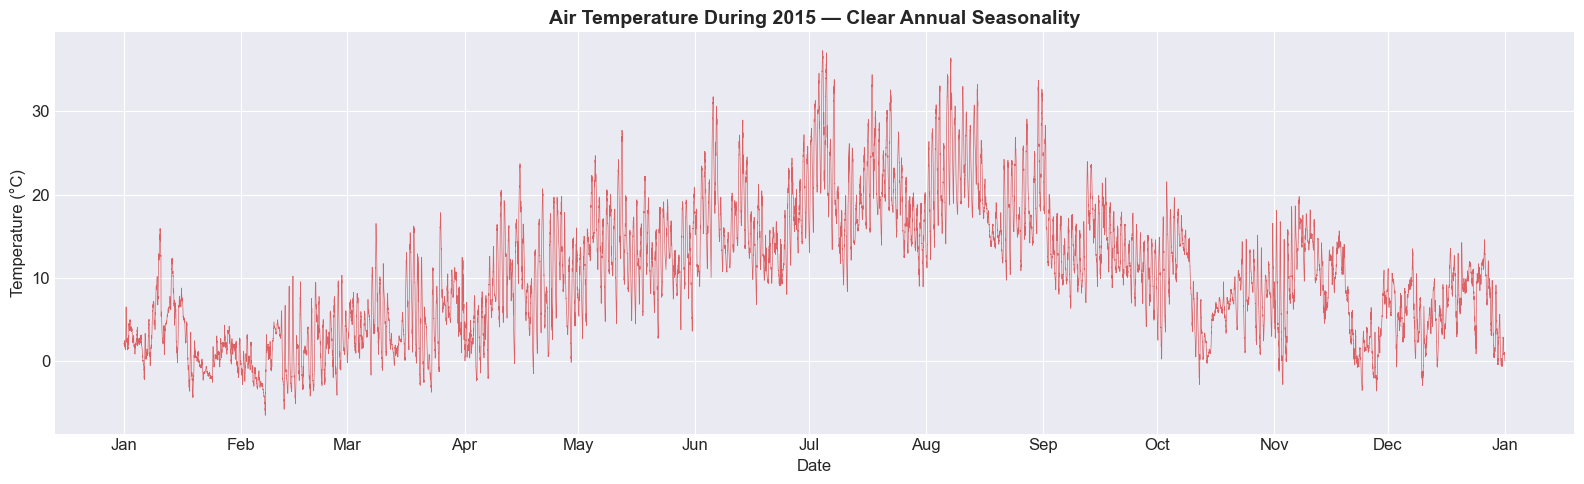

In [19]:
# Zoom in: Temperature over a single year (2015) to see seasonal patterns more clearly
df_2015 = df.loc['2015']

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_2015.index, df_2015['Temperature'], linewidth=0.5, color='tab:red', alpha=0.7)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Air Temperature During 2015 — Clear Annual Seasonality', fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

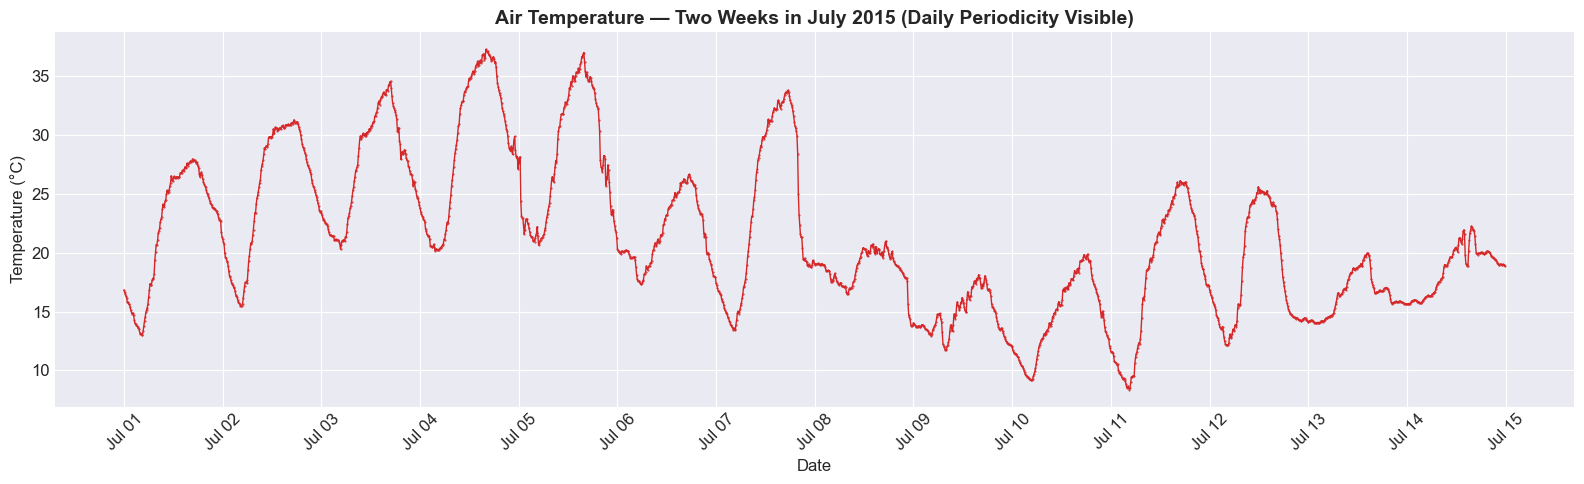

In [20]:
# Zoom in further: Temperature over 2 weeks to see daily patterns
df_2weeks = df.loc['2015-07-01':'2015-07-14']

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_2weeks.index, df_2weeks['Temperature'], linewidth=1, color='tab:red', marker='.', markersize=1)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Air Temperature — Two Weeks in July 2015 (Daily Periodicity Visible)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.4 Seasonality Analysis

Temperature is expected to have strong:
- **Annual seasonality** (summer vs winter)
- **Daily seasonality** (day vs night)

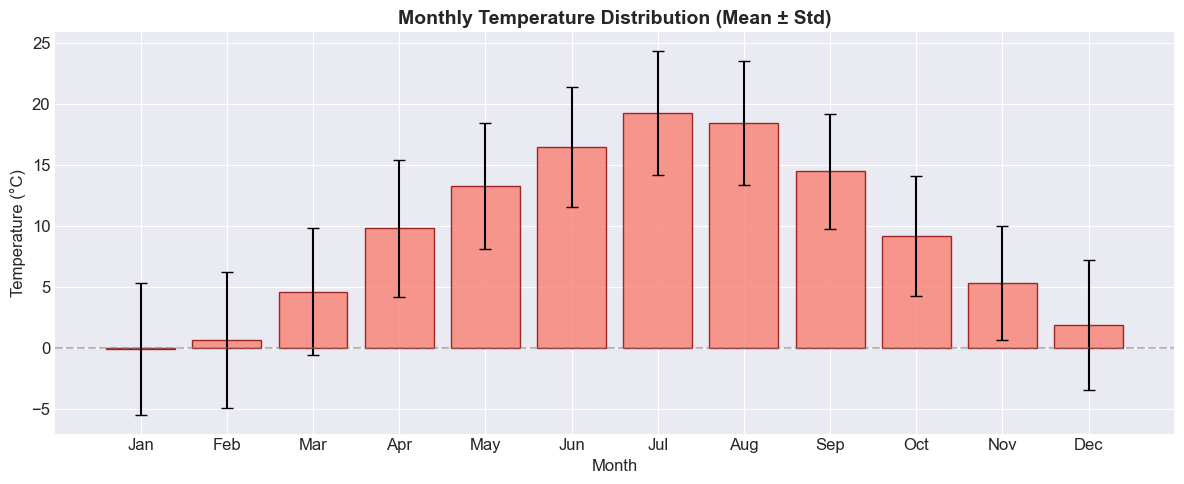

      mean   std    min    max
Jan  -0.13  5.42 -23.01  15.95
Feb   0.60  5.56 -21.04  14.47
Mar   4.58  5.22 -13.51  22.10
Apr   9.77  5.61  -4.27  30.65
May  13.23  5.17  -1.98  30.66
Jun  16.41  4.91   3.48  34.36
Jul  19.26  5.08   7.00  37.28
Aug  18.40  5.11   5.05  36.40
Sep  14.45  4.72   1.13  31.33
Oct   9.13  4.91  -5.80  25.78
Nov   5.33  4.67  -9.15  21.22
Dec   1.85  5.33 -17.67  14.77


In [21]:
# Monthly temperature statistics
monthly_stats = df['Temperature'].groupby(df.index.month).agg(['mean', 'std', 'min', 'max'])
monthly_stats.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_stats.index, monthly_stats['mean'], 
       yerr=monthly_stats['std'], capsize=4, color='salmon', edgecolor='darkred', alpha=0.8)
ax.set_xlabel('Month')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Monthly Temperature Distribution (Mean ± Std)', fontsize=14, fontweight='bold')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(monthly_stats.round(2))

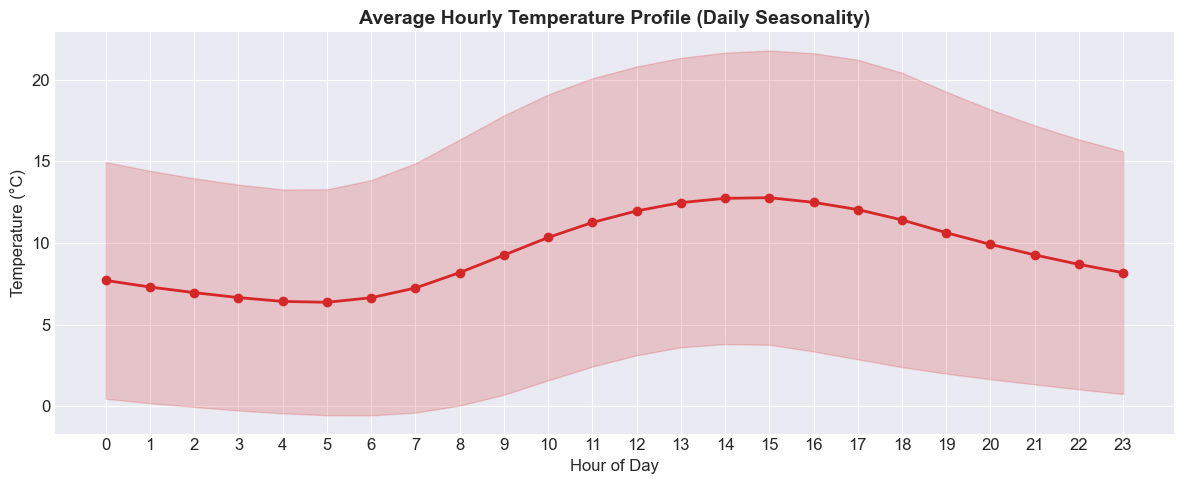

In [22]:
# Hourly temperature profile (daily seasonality)
hourly_stats = df['Temperature'].groupby(df.index.hour).agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_stats.index, hourly_stats['mean'], 'o-', color='tab:red', linewidth=2, markersize=6)
ax.fill_between(hourly_stats.index, 
                hourly_stats['mean'] - hourly_stats['std'],
                hourly_stats['mean'] + hourly_stats['std'], 
                alpha=0.2, color='tab:red')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Average Hourly Temperature Profile (Daily Seasonality)', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

### 3.5 Variable Distributions

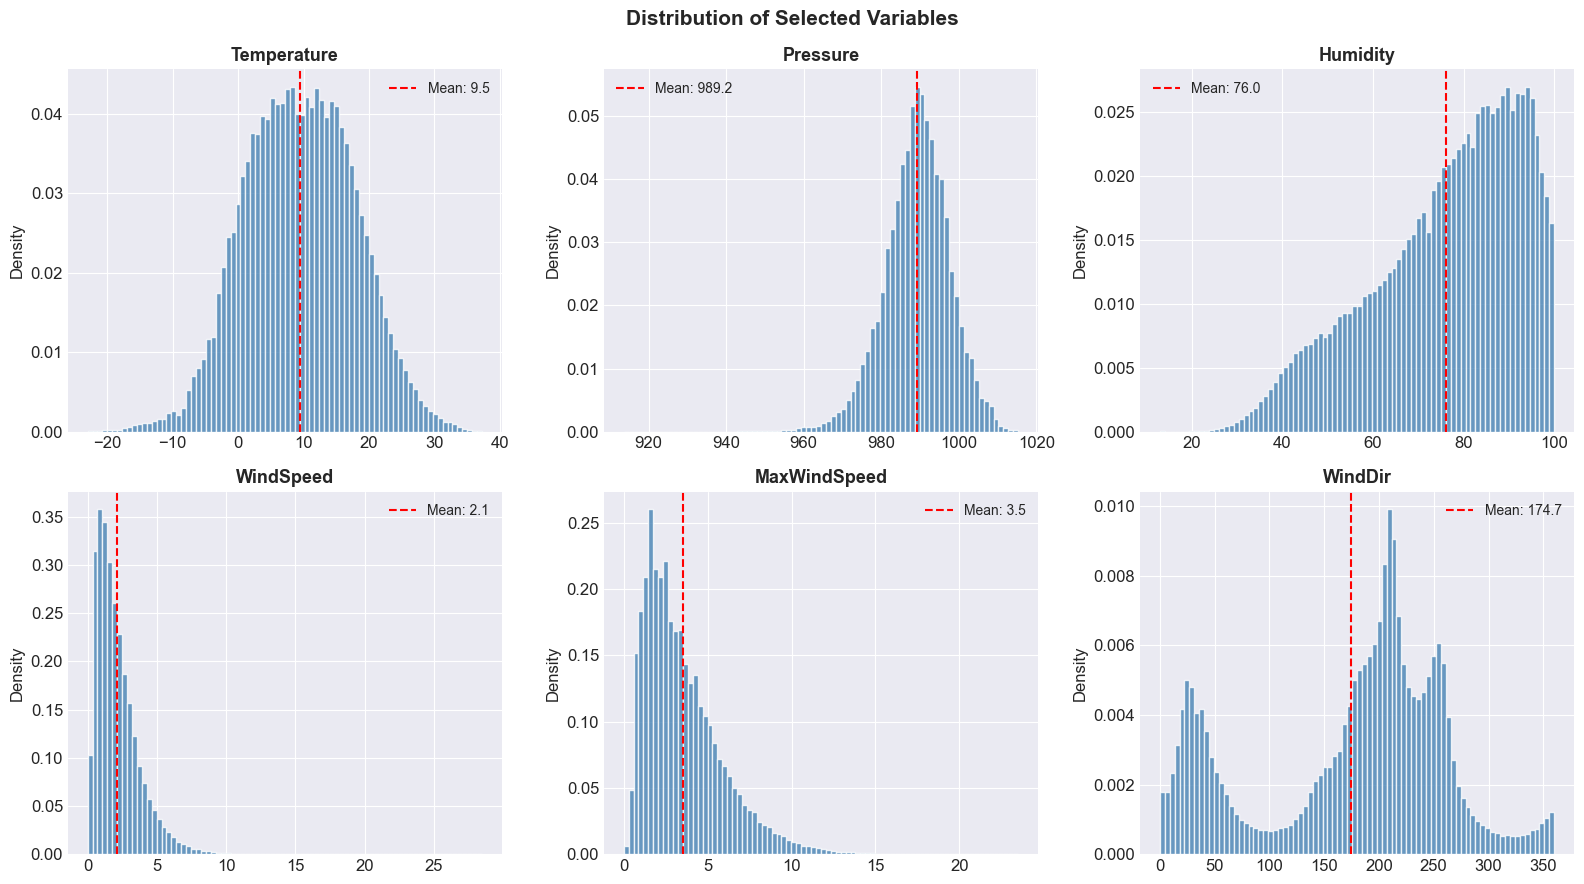

In [23]:
# Distribution of each variable
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(SELECTED_FEATURES):
    axes[i].hist(df[col], bins=80, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Density')
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=10)

fig.suptitle('Distribution of Selected Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Correlation Analysis

Understanding the linear relationships between variables helps us understand which features might be most informative for predicting temperature.

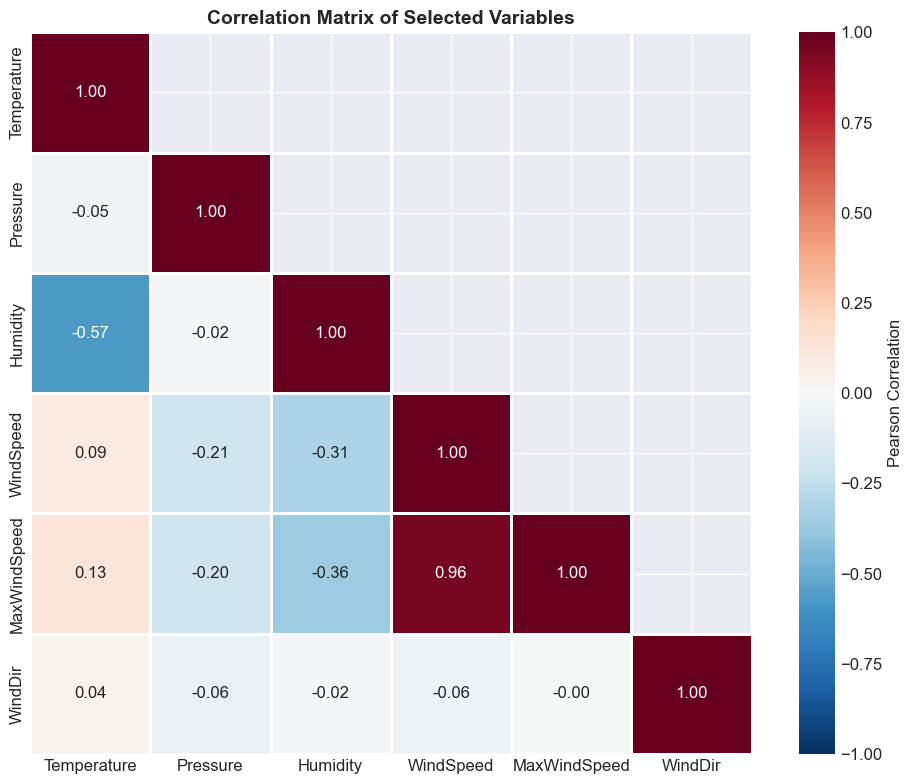

Correlations with target (Temperature):
  MaxWindSpeed        : +0.125
  WindSpeed           : +0.088
  WindDir             : +0.039
  Pressure            : -0.045
  Humidity            : -0.572


In [24]:
# Correlation heatmap
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=1, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Correlation Matrix of Selected Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlations with target
print(f"Correlations with target ({TARGET}):")
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
for feat, corr in target_corr.items():
    print(f"  {feat:20s}: {corr:+.3f}")

### 3.7 Autocorrelation Analysis

Autocorrelation helps us understand how past values relate to future values. Crucial for choosing the lookback window "L".

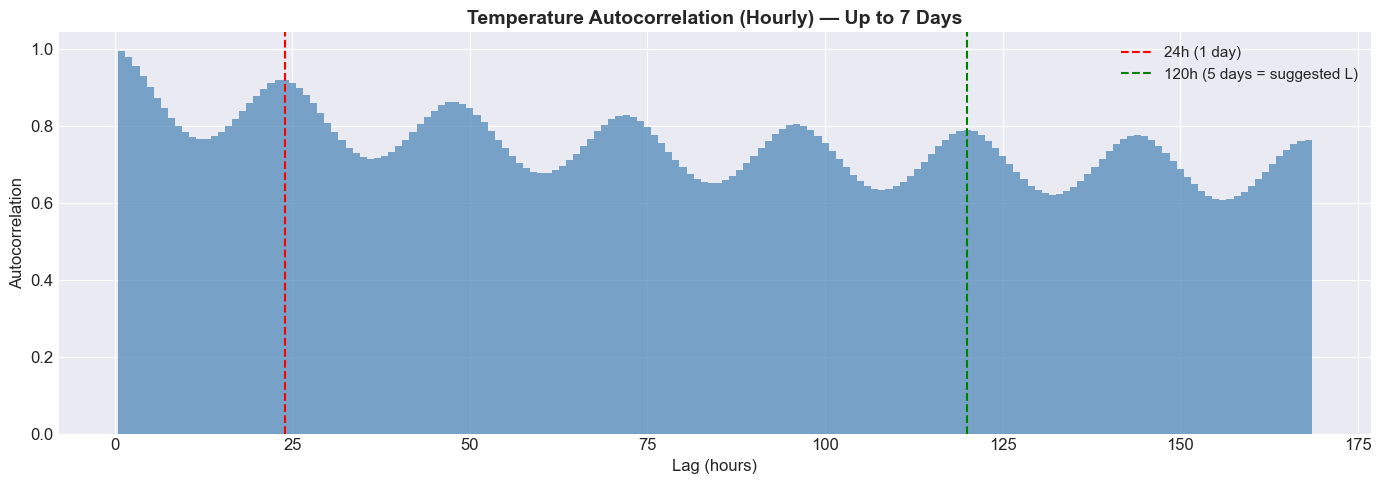

  Lag   1h (0.0 days): autocorr = 0.9936
  Lag   6h (0.2 days): autocorr = 0.8735
  Lag  12h (0.5 days): autocorr = 0.7660
  Lag  24h (1.0 days): autocorr = 0.9192
  Lag  48h (2.0 days): autocorr = 0.8630
  Lag  72h (3.0 days): autocorr = 0.8274
  Lag 120h (5.0 days): autocorr = 0.7899
  Lag 168h (7.0 days): autocorr = 0.7637


In [25]:
# Resample to hourly for faster autocorrelation computation
temp_hourly = df[TARGET].resample('1h').mean()

# Compute autocorrelation for up to 7 days (168 hours)
max_lag = 168  # 7 days in hours
autocorr = [temp_hourly.autocorr(lag=lag) for lag in range(1, max_lag + 1)]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(1, max_lag + 1), autocorr, width=1, color='steelblue', alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.5)

# Mark key points
ax.axvline(x=24, color='red', linestyle='--', linewidth=1.5, label='24h (1 day)')
ax.axvline(x=120, color='green', linestyle='--', linewidth=1.5, label='120h (5 days = suggested L)')

ax.set_xlabel('Lag (hours)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Temperature Autocorrelation (Hourly) — Up to 7 Days', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print key autocorrelation values
for lag in [1, 6, 12, 24, 48, 72, 120, 168]:
    print(f"  Lag {lag:3d}h ({lag/24:.1f} days): autocorr = {autocorr[lag-1]:.4f}")

### 3.8. Data Preparation

#### 3.8.1. Handle Anomalies

Based on the EDA findings, we correct any identified data quality issues (e.g., sensor error values in wind speed).

In [26]:
df_clean = df.copy()

# Replace anomalous wind speed values with NaN, then interpolate
# Wind speed cannot be negative, and values above 50 m/s are unrealistic for this station
for col in ['WindSpeed', 'MaxWindSpeed']:
    mask = (df_clean[col] < 0) | (df_clean[col] > 50)
    n_anomalous = mask.sum()
    if n_anomalous > 0:
        print(f"Replacing {n_anomalous} anomalous values in '{col}' with NaN")
        df_clean.loc[mask, col] = np.nan

# Interpolate NaN values using linear interpolation (appropriate for continuous time series)
n_nans_before = df_clean.isnull().sum().sum()
df_clean = df_clean.interpolate(method='linear')
n_nans_after = df_clean.isnull().sum().sum()

print(f"\nNaN values before interpolation: {n_nans_before}")
print(f"NaN values after interpolation:  {n_nans_after}")
print(f"\nCleaned dataset shape: {df_clean.shape}")
df_clean.describe().round(2)



NaN values before interpolation: 0
NaN values after interpolation:  0

Cleaned dataset shape: (420551, 6)


,Temperature,Pressure,Humidity,WindSpeed,MaxWindSpeed,WindDir
count,420551.00,420551.00,420551.00,420551.00,420551.00,420551.00
mean,9.45,989.21,76.01,2.13,3.53,174.74
std,8.42,8.36,16.48,1.54,2.34,86.68
min,-23.01,913.60,12.95,0.00,0.00,0.00
25%,3.36,984.20,65.21,0.99,1.76,124.90
50%,9.42,989.58,79.30,1.76,2.96,198.10
75%,15.47,994.72,89.40,2.86,4.74,234.10
max,37.28,1015.35,100.00,28.49,23.50,360.00


### 3.9. Resample to Hourly Resolution

The original data is sampled every 10 minutes. We resample to **hourly** resolution to reduce computational cost while retaining meaningful patterns.

In [27]:
# Resample to hourly by taking the mean of each hour
df_hourly = df_clean.resample('1h').mean()

print(f"Original shape (10-min):  {df_clean.shape}")
print(f"Resampled shape (hourly): {df_hourly.shape}")
print(f"Reduction factor: {len(df_clean) / len(df_hourly):.1f}x")

# Check for NaN after resampling
print(f"\nNaN after resampling: {df_hourly.isnull().sum().sum()}")
df_hourly = df_hourly.interpolate(method='linear')
print(f"Final hourly shape: {df_hourly.shape}")

df_hourly.head(10)

Original shape (10-min):  (420551, 6)
Resampled shape (hourly): (70129, 6)
Reduction factor: 6.0x

NaN after resampling: 528
Final hourly shape: (70129, 6)


,Temperature,Pressure,Humidity,WindSpeed,MaxWindSpeed,WindDir
Date Time,,,,,,
2009-01-01 00:00:00,-8.304000,996.528000,93.780000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,-8.065000,996.525000,93.933333,0.316667,0.711667,172.416667
2009-01-01 02:00:00,-8.763333,996.745000,93.533333,0.248333,0.606667,196.816667
2009-01-01 03:00:00,-8.896667,996.986667,93.200000,0.176667,0.606667,157.083333
2009-01-01 04:00:00,-9.348333,997.158333,92.383333,0.290000,0.670000,150.093333
2009-01-01 05:00:00,-9.716667,997.510000,92.383333,0.325000,0.813333,118.886667
2009-01-01 06:00:00,-9.298333,997.955000,92.483333,0.818333,1.501667,145.235000
2009-01-01 07:00:00,-8.543333,998.685000,93.050000,1.405000,1.941667,326.700000
2009-01-01 08:00:00,-7.926667,999.376667,92.616667,0.506667,0.876667,219.566667


In [28]:
# Calculate time differences between consecutive rows
time_diffs_hourly = df_hourly.index.to_series().diff().iloc[1:]

# Expected interval is now 1 HOUR
expected_interval_hourly = pd.Timedelta(hours=1)

# Find irregular intervals
irregular_intervals_hourly = time_diffs_hourly[time_diffs_hourly != expected_interval_hourly]

print(f"Number of irregular intervals (hours): {len(irregular_intervals_hourly)}")


Number of irregular intervals (hours): 0


### 4. Train / Validation / Test Split

For time series, we use a chronological split (no shuffling) to avoid data leakage:
- Train: first 70% of the data
- Validation: next 15%
- Test: final 15%

Train: 49,090 samples (70.0%) | 2009-01-01 00:00:00 → 2014-08-08 09:00:00
Val:   10,519 samples (15.0%) | 2014-08-08 10:00:00 → 2015-10-20 16:00:00
Test:  10,520 samples (15.0%) | 2015-10-20 17:00:00 → 2017-01-01 00:00:00


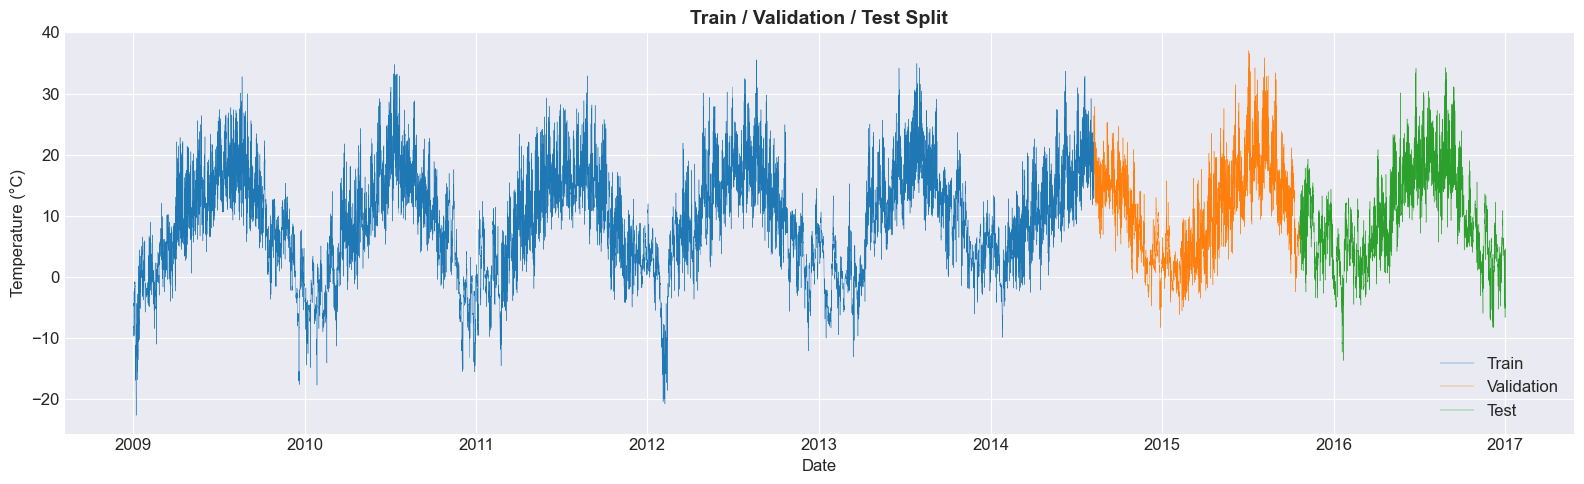

In [29]:
# Chronological split
n = len(df_hourly)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df_hourly.iloc[:train_end]
df_val = df_hourly.iloc[train_end:val_end]
df_test = df_hourly.iloc[val_end:]

print(f"Train: {len(df_train):,} samples ({len(df_train)/n*100:.1f}%) | {df_train.index[0]} → {df_train.index[-1]}")
print(f"Val:   {len(df_val):,} samples ({len(df_val)/n*100:.1f}%) | {df_val.index[0]} → {df_val.index[-1]}")
print(f"Test:  {len(df_test):,} samples ({len(df_test)/n*100:.1f}%) | {df_test.index[0]} → {df_test.index[-1]}")

# Visualize the split
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_train.index, df_train[TARGET], label='Train', color='tab:blue', linewidth=0.3)
ax.plot(df_val.index, df_val[TARGET], label='Validation', color='tab:orange', linewidth=0.3)
ax.plot(df_test.index, df_test[TARGET], label='Test', color='tab:green', linewidth=0.3)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Train / Validation / Test Split', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 4.1 Normalization

We apply **StandardScaler** (zero mean, unit variance), fit **only on the training set** to avoid data leakage.

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data only
scaler.fit(df_train.values)

# Transform all splits
train_scaled = pd.DataFrame(scaler.transform(df_train.values), index=df_train.index, columns=df_train.columns)
val_scaled = pd.DataFrame(scaler.transform(df_val.values), index=df_val.index, columns=df_val.columns)
test_scaled = pd.DataFrame(scaler.transform(df_test.values), index=df_test.index, columns=df_test.columns)

# Store scaler parameters for later inverse transform of predictions
target_idx = list(df_train.columns).index(TARGET)
target_mean = scaler.mean_[target_idx]
target_std = scaler.scale_[target_idx]
print(f"Target ({TARGET}) — mean: {target_mean:.4f}, std: {target_std:.4f}")

print(f"\nScaled training data statistics:")
train_scaled.describe().round(2)

Target (Temperature) — mean: 9.1096, std: 8.6450

Scaled training data statistics:


,Temperature,Pressure,Humidity,WindSpeed,MaxWindSpeed,WindDir
count,49090.00,49090.00,49090.00,49090.00,49090.00,49090.00
mean,-0.00,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-3.67,-6.48,-3.78,-1.48,-1.62,-2.33
25%,-0.71,-0.61,-0.66,-0.75,-0.77,-0.48
50%,0.01,0.05,0.20,-0.23,-0.22,0.24
75%,0.72,0.65,0.81,0.49,0.54,0.69
max,3.06,2.91,1.46,7.40,7.49,2.46


### 4.2. Covariate variables
To help the models extract temporal patterns more effectively, we opted to enrich the raw meteorological inputs with time-based features. Representing hours (0–23) or days (1–365) as plain integers creates a mathematical discontinuity — the model would treat the end of a cycle as numerically far from its start, when in reality they are adjacent (e.g. 23:00 is immediately before 00:00, and December 31st is immediately before January 1st).

To resolve this, we applied Sine and Cosine encoding, projecting each time variable onto a circle. This ensures the cyclic structure is preserved, allowing both the GRU and Transformer to correctly understand that the end of a day/year wraps directly back to its beginning.

Four covariates are added (optionally, at model training time):
- hour_sin, hour_cos — daily cycle (period = 24 hours)
- year_sin, year_cos — yearly cycle (period = 365.24 days)


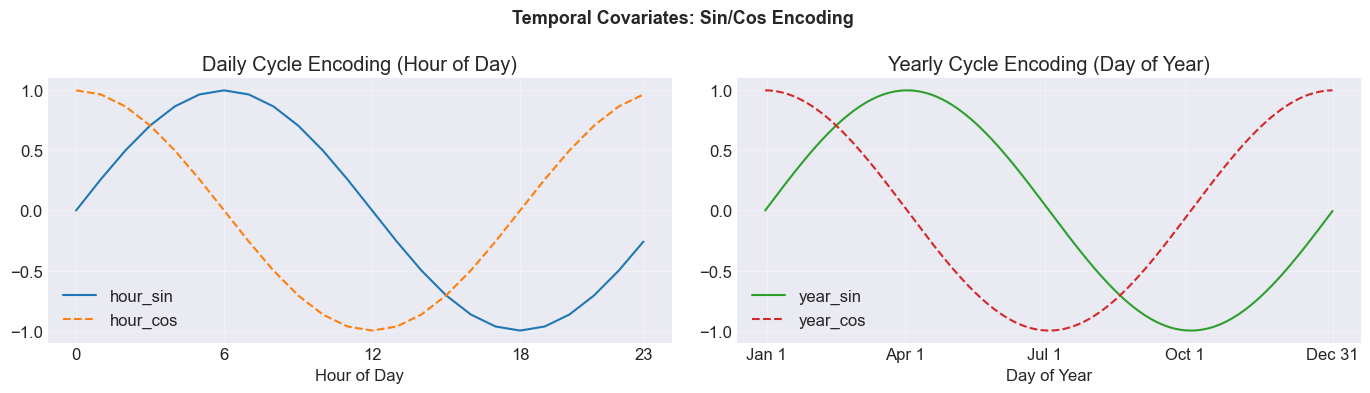

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Demonstrate the sin/cos encoding on a sample time axis
hours = np.arange(0, 24)
days  = np.arange(0, 366)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Daily Cycle
axes[0].plot(hours, np.sin(2 * np.pi * hours / 24), label='hour_sin', color='#1f77b4')
axes[0].plot(hours, np.cos(2 * np.pi * hours / 24), label='hour_cos', color='#ff7f0e', linestyle='--')
axes[0].set_title('Daily Cycle Encoding (Hour of Day)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_xticks([0, 6, 12, 18, 23])
axes[0].legend()
axes[0].grid(alpha=0.3)

# Yearly Cycle
axes[1].plot(days, np.sin(2 * np.pi * days / 365.24), label='year_sin', color='#2ca02c')
axes[1].plot(days, np.cos(2 * np.pi * days / 365.24), label='year_cos', color='#d62728', linestyle='--')
axes[1].set_title('Yearly Cycle Encoding (Day of Year)')
axes[1].set_xlabel('Day of Year')
axes[1].set_xticks([1, 90, 180, 270, 365])
axes[1].set_xticklabels(['Jan 1', 'Apr 1', 'Jul 1', 'Oct 1', 'Dec 31'])
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Temporal Covariates: Sin/Cos Encoding', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.3. Save Prepared Data

Save the prepared data for use in the modeling notebook.

In [32]:
import pickle

# Save to disk
prepared_data = {
    'train_scaled': train_scaled,
    'val_scaled': val_scaled,
    'test_scaled': test_scaled,
    'scaler': scaler,
    'target_col': TARGET,
    'target_idx': target_idx,
    'target_mean': target_mean,
    'target_std': target_std,
    'feature_columns': list(df_train.columns),
}

with open('prepared_data.pkl', 'wb') as f:
    pickle.dump(prepared_data, f)

print("Prepared data saved to 'prepared_data.pkl'")
print(f"\nSummary:")
print(f"  Features: {prepared_data['feature_columns']}")
print(f"  Target: {prepared_data['target_col']}")
print(f"  Train samples: {len(train_scaled):,}")
print(f"  Val samples:   {len(val_scaled):,}")
print(f"  Test samples:  {len(test_scaled):,}")

Prepared data saved to 'prepared_data.pkl'

Summary:
  Features: ['Temperature', 'Pressure', 'Humidity', 'WindSpeed', 'MaxWindSpeed', 'WindDir']
  Target: Temperature
  Train samples: 49,090
  Val samples:   10,519
  Test samples:  10,520


### 4.4. Window Setup

In [33]:
# Define window length and forecast horizon
L = 120   # number of past timesteps (input window)
H = 24   # number of future timesteps to predict

In [34]:
def create_windows_univariate(series: np.ndarray , L : int, H: int):
    """
    Convert a 1D time series into input-output pairs.

    Parameters
    ----------
    series : np.ndarray
        Univariate time series of shape (T,)
    L : int
        Length of the input window
    H : int
        Forecast horizon

    Returns
    -------
    X : np.ndarray
        Input windows of shape (N, L)
    y : np.ndarray
        Target windows of shape (N, H)
    """
    X, y = [], []

    for i in range(len(series) - L - H + 1):
        X.append(series[i : i + L])
        y.append(series[i + L : i + L + H])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [ ]:
# Apply windowing to each split separately
X_train_u, y_train_u = create_windows_univariate(train_scaled, L, H)
X_val_u,   y_val_u   = create_windows_univariate(val_scaled,   L, H)
X_test_u,  y_test_u  = create_windows_univariate(test_scaled,  L, H)

print("Original raw time series length (T):", len(train_scaled) + len(val_scaled) + len(test_scaled))
print("\nRaw split sizes (in time steps):")
print("  Train segment :", len(train_scaled))
print("  Val segment   :", len(val_scaled))
print("  Test segment  :", len(test_scaled))

print("\nSupervised dataset (number of windows per split):")
print("  Train windows :", X_train_u.shape[0])
print("  Val windows   :", X_val_u.shape[0])
print("  Test windows  :", X_test_u.shape[0])

print("\nWindow configuration:")
print("  Input length  (L):", L,  "past time steps per sample")
print("  Target length (H):", H,  "future time steps per sample")

Original raw time series length (T): 70129

Raw split sizes (in time steps):
  Train segment : 49090
  Val segment   : 10519
  Test segment  : 10520

Supervised dataset (number of windows per split):
  Train windows : 48947
  Val windows   : 10376
  Test windows  : 10377

Window configuration:
  Input length  (L): 120 past time steps per sample
  Target length (H): 24 future time steps per sample


In [36]:
# Tensor shapes
print("\nTensor shapes:")
print(f"  X_train_u: {X_train_u.shape} (samples, L)")
print(f"  y_train_u: {y_train_u.shape} (samples, H)")
print(f"  X_val_u:   {X_val_u.shape} (samples, L)")
print(f"  y_val_u:   {y_val_u.shape} (samples, H)")
print(f"  X_test_u:  {X_test_u.shape} (samples, L)")
print(f"  y_test_u:  {y_test_u.shape} (samples, H)")


Tensor shapes:
  X_train_u: (48947, 120, 6) (samples, L)
  y_train_u: (48947, 24, 6) (samples, H)
  X_val_u:   (10376, 120, 6) (samples, L)
  y_val_u:   (10376, 24, 6) (samples, H)
  X_test_u:  (10377, 120, 6) (samples, L)
  y_test_u:  (10377, 24, 6) (samples, H)


# 5.0 Create DataLoaders

In [37]:
# DataLoaders creation 
import torch
from torch.utils.data import TensorDataset, DataLoader

def create_dataloader(X, y, batch_size=32, shuffle=False):
    dataset = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# X arrays: (N, L, 6) — all 6 features including Temperature as input
# y arrays: (N, H)    — only Temperature as target
target_idx = SELECTED_FEATURES.index(TARGET)

train_loader = create_dataloader(X_train_u, y_train_u[:, :, target_idx], batch_size=32, shuffle=True)
val_loader   = create_dataloader(X_val_u,   y_val_u[:, :, target_idx],   batch_size=32, shuffle=False)
test_loader  = create_dataloader(X_test_u,  y_test_u[:, :, target_idx],  batch_size=32, shuffle=False)


In [38]:
torch.save({
    'train_loader': train_loader,
    'val_loader': val_loader,
    'test_loader': test_loader,
    'target_col': TARGET,
    'target_idx': target_idx,
    'feature_columns': prepared_data['feature_columns'],
    'target_mean': target_mean,
    'target_std': target_std
}, 'dataloaders.pt')
